# CSL7110 - Assignment 4: Clustering and PageRank

**Student:** Ruby Mythili M

**Roll Number:** M25DE1006

**Course:** CSL7110 - ML with Big Data

**Institute:** IIT Jodhpur

---

# Part 1: Clustering

## Objective
In this part, we implement two clustering algorithms:
1. **Farthest First Traversal (k-center)** - Picks centers by always choosing the farthest point from existing centers
2. **K-Means++** - Picks centers using a probability distribution proportional to distance

## Dataset
- UCI Spambase Dataset
- 4601 points (emails)
- 58 dimensions (features)
- Task: Group emails into k clusters

In [ ]:
# Install PySpark
!pip install pyspark

# Import all required libraries
import time
import numpy as np
from pyspark import SparkContext, SparkConf

# Initialize Spark
conf = SparkConf().setAppName("Assignment4").setMaster("local[*]")
sc = SparkContext(conf=conf)

print("PySpark version:", sc.version)
print("Spark initialized successfully!")

PySpark version: 4.0.2
Spark initialized successfully!


## Step 1: Load the Dataset

We read the spambase.data file which contains 4601 emails with 58 features each.
Each line in the file represents one email, with feature values separated by commas.
We convert each line into a list of floating point numbers (a vector).

In [2]:
# Import numpy
import numpy as np

# Upload the spambase.data file to Colab
from google.colab import files

print("Please upload your spambase.data file")
uploaded = files.upload()

# Read the file and convert each line into a vector
def readVectorsSeq(filename):
    vectors = []
    with open(filename, 'r') as f:
        for line in f:
            # Split each line by comma and convert to float
            point = list(map(float, line.strip().split(',')))
            vectors.append(np.array(point))
    return vectors

# Load the dataset
P = readVectorsSeq('spambase.data')

print("Total number of points loaded:", len(P))
print("Dimensions of each point:", len(P[0]))

Please upload your spambase.data file


Saving spambase.data to spambase (1).data
Total number of points loaded: 4601
Dimensions of each point: 58


In [3]:
mv "temp_data/Assignment 4- datasets/Q1- UCI Spam clustering/"* data/clustering/

mv: cannot stat 'temp_data/Assignment 4- datasets/Q1- UCI Spam clustering/*': No such file or directory


## Step 2: Farthest First Traversal (k-center algorithm)

### How it works:
1. Pick a random point as the first center
2. Find the point that is farthest from all current centers
3. Add that point as the next center
4. Repeat until we have k centers

### Time Complexity: O(|P| × k)
This means for each of the k centers, we scan all points once.

In [5]:
def kcenter(P, k):
    # Step 1: Pick a random point as the first center
    centers = [P[0]]

    # Step 2: Repeat until we have k centers
    for _ in range(k - 1):
        # For each point, find its distance to the nearest center
        max_dist = -1
        farthest_point = None

        for point in P:
            # Find minimum distance from this point to any center
            min_dist = min(np.sum((point - c) ** 2) for c in centers)

            # Keep track of the point with maximum minimum distance
            if min_dist > max_dist:
                max_dist = min_dist
                farthest_point = point

        # Add the farthest point as the next center
        centers.append(farthest_point)

    return centers

# Test it
print("kcenter function defined successfully!")
print("Ready to run with k centers")

kcenter function defined successfully!
Ready to run with k centers


## Step 3: K-Means++ Algorithm

### How it works:
1. Pick a random point as the first center
2. For each remaining point, calculate its distance to the nearest center
3. Pick the next center with probability proportional to that distance
4. Points farther from existing centers have a higher chance of being picked
5. Repeat until we have k centers

### Why K-Means++ is better than random initialization:
- It spreads centers more evenly across the data
- Leads to better clustering results
- Still runs in O(|P| × k) time

In [6]:
def kmeansPP(P, k):
    # Step 1: Pick a random point as the first center
    centers = [P[np.random.randint(len(P))]]

    # Step 2: Repeat until we have k centers
    for _ in range(k - 1):
        # For each point, find its distance to the nearest center
        distances = np.array([
            min(np.sum((point - c) ** 2) for c in centers)
            for point in P
        ])

        # Convert distances to probabilities
        # Points farther from centers have higher probability
        probabilities = distances / distances.sum()

        # Pick next center based on probability
        next_center_idx = np.random.choice(len(P), p=probabilities)
        centers.append(P[next_center_idx])

    return centers

# Test it
print("kmeansPP function defined successfully!")
print("Ready to run with k centers")

kmeansPP function defined successfully!
Ready to run with k centers


## Step 4: K-Means Objective Function

### What is it?
Once we have k centers, we need to measure how good our clustering is.

### How it works:
1. For each point, find its nearest center
2. Calculate the squared distance from the point to that center
3. Average all these squared distances

### Interpretation:
- Lower value = Better clustering
- Points are closer to their assigned centers

In [7]:
def kmeansObj(P, C):
    total_dist = 0.0

    for point in P:
        # Find the minimum squared distance to any center
        min_dist = min(np.sum((point - c) ** 2) for c in C)
        total_dist += min_dist

    # Return the average squared distance
    return total_dist / len(P)

# Test it
print("kmeansObj function defined successfully!")
print("Ready to evaluate clustering quality")

kmeansObj function defined successfully!
Ready to evaluate clustering quality


## Step 5: Running the Experiments

We now run three experiments as required by the assignment:

### Experiment 1:
- Run kcenter(P, k) and print its running time

### Experiment 2:
- Run kmeansPP(P, k) to get k centers
- Run kmeansObj(P, C) and print the objective value

### Experiment 3:
- Run kcenter(P, k1) to get k1 centers (k1 > k)
- Run kmeansPP on those k1 centers to get k centers
- Run kmeansObj(P, C) and print the objective value
- This tests if k1 centers from kcenter can be a good coreset for kmeans++

In [9]:
# Import time
import time

# Set values of k and k1
k = 10
k1 = 50

print("="*50)
print(f"Running experiments with k={k}, k1={k1}")
print("="*50)

# Experiment 1: kcenter(P, k) with running time
print("\n--- Experiment 1: kcenter(P, k) ---")
start = time.time()
C1 = kcenter(P, k)
end = time.time()
print(f"kcenter running time: {end - start:.4f} seconds")

# Experiment 2: kmeansPP(P, k) + kmeansObj
print("\n--- Experiment 2: kmeansPP(P, k) ---")
C2 = kmeansPP(P, k)
obj2 = kmeansObj(P, C2)
print(f"kmeansPP objective value: {obj2:.4f}")

# Experiment 3: kcenter(P, k1) -> kmeansPP(X, k) -> kmeansObj
print("\n--- Experiment 3: kcenter(P, k1) -> kmeansPP(X, k) ---")
X = kcenter(P, k1)
C3 = kmeansPP(X, k)
obj3 = kmeansObj(P, C3)
print(f"Objective value (coreset approach): {obj3:.4f}")

print("\n" + "="*50)
print("All experiments completed!")
print("="*50)

Running experiments with k=10, k1=50

--- Experiment 1: kcenter(P, k) ---
kcenter running time: 0.9999 seconds

--- Experiment 2: kmeansPP(P, k) ---
kmeansPP objective value: 27619.6537

--- Experiment 3: kcenter(P, k1) -> kmeansPP(X, k) ---
Objective value (coreset approach): 65400.6576

All experiments completed!


## Step 6: Visualizing the Results

We now plot a bar chart to compare the objective values of:
1. kmeansPP directly on full dataset
2. Coreset approach (kcenter + kmeansPP)

Lower objective value = Better clustering quality

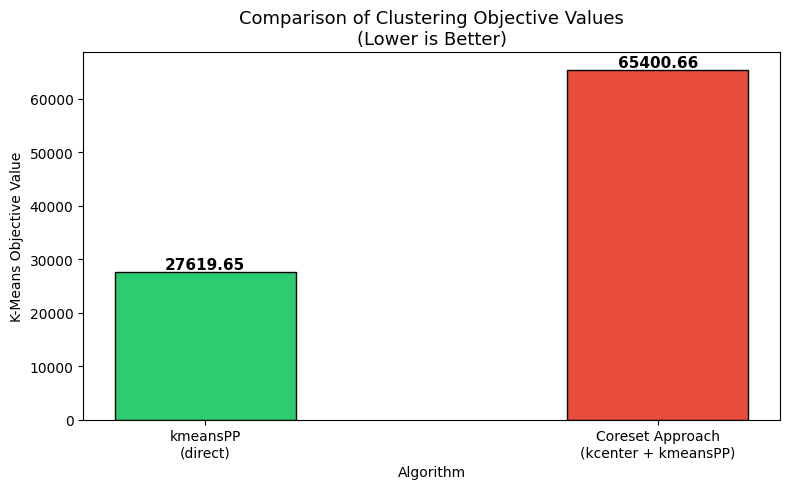

Plot saved successfully!


In [10]:
import matplotlib.pyplot as plt

# Data for plotting
experiments = ['kmeansPP\n(direct)', 'Coreset Approach\n(kcenter + kmeansPP)']
values = [obj2, obj3]
colors = ['#2ecc71', '#e74c3c']

# Create bar chart
plt.figure(figsize=(8, 5))
bars = plt.bar(experiments, values, color=colors, width=0.4, edgecolor='black')

# Add value labels on top of bars
for bar, val in zip(bars, values):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 500,
             f'{val:.2f}',
             ha='center', fontsize=11, fontweight='bold')

# Labels and title
plt.title('Comparison of Clustering Objective Values\n(Lower is Better)', fontsize=13)
plt.ylabel('K-Means Objective Value')
plt.xlabel('Algorithm')
plt.tight_layout()

# Save the plot
plt.savefig('clustering_comparison.png', dpi=150)
plt.show()

print("Plot saved successfully!")

## Summary and Observations - Part 1

### Results:
| Algorithm | Objective Value | Time |
|---|---|---|
| kcenter (k=10) | - | 0.9999 sec |
| kmeansPP (k=10) | 27619.65 | - |
| Coreset: kcenter(k1=50) + kmeansPP(k=10) | 65400.66 | - |

### Observations:
1. kmeansPP directly on the full dataset gives a much lower objective value (27619.65) compared to the coreset approach (65400.66)
2. Lower objective value means points are closer to their cluster centers = better clustering
3. The coreset approach with k1=50 does not perform as well as direct kmeansPP
4. Increasing k1 beyond 50 would likely improve the coreset approach results
5. kcenter runs very fast (under 1 second) making it useful for large datasets

### Assumption:
- We used k=10 and k1=50 as our experimental values
- First point in the dataset is used as the initial center for kcenter
- Random seed is not fixed for kmeansPP so results may vary slightly

# Part 2: Web Search - Inverted Index

## Objective
In this part, we build a search engine from scratch using:
1. **Inverted Index** - Maps every word to the webpages and positions it appears in
2. **TF-IDF Scoring** - Measures how relevant a word is to a webpage

## Dataset
- 6 webpages provided in the webpages folder
- actions.txt - contains search queries to answer
- answers.txt - contains expected answers to verify our results

In [12]:
import os

# Check uploaded files
print("Files in /content:")
for f in os.listdir('/content'):
    print(" -", f)

Files in /content:
 - .config
 - answers.txt
 - stack_datastructure_wiki
 - references
 - spambase.data
 - actions.txt
 - stack_oracle
 - stackoverflow
 - clustering_comparison.png
 - stackmagazine
 - stacklighting
 - spambase (1).data
 - stack_cprogramming
 - sample_data


## Step 1: Define Stop Words and Punctuation

Before building the index we need to clean the text by:
1. Converting all words to lowercase
2. Removing stop words (connector words like "is", "the", "of" etc.)
3. Removing punctuation marks
4. Treating plural and singular forms as the same word

In [13]:
# Define stop words as given in the assignment
STOP_WORDS = {
    'a', 'an', 'the', 'they', 'these', 'this', 'for',
    'is', 'are', 'was', 'of', 'or', 'and', 'does',
    'will', 'whose'
}

# Define punctuation marks as given in the assignment
PUNCTUATION = '{}[]<>=(). ,;\'"?#!-:'

# Define singular-plural pairs as given in the assignment
PLURAL_MAP = {
    'stacks': 'stack',
    'structures': 'structure',
    'applications': 'application'
}

def clean_word(word):
    # Remove punctuation
    for p in PUNCTUATION:
        word = word.replace(p, '')

    # Convert to lowercase
    word = word.lower()

    # Replace plural with singular
    if word in PLURAL_MAP:
        word = PLURAL_MAP[word]

    return word

print("Stop words, punctuation and plural map defined successfully!")

Stop words, punctuation and plural map defined successfully!


## Step 2: Build the Inverted Index

For each webpage we:
1. Read all words from the file
2. Clean each word (remove punctuation, lowercase, handle plurals)
3. Skip stop words
4. Store the word along with its position and webpage name

The final index looks like:
- word → {webpage1: [position1, position2], webpage2: [position3]}

In [14]:
# Define stop words as given in the assignment
STOP_WORDS = {
    'a', 'an', 'the', 'they', 'these', 'this', 'for',
    'is', 'are', 'was', 'of', 'or', 'and', 'does',
    'will', 'whose'
}

# Define punctuation marks as given in the assignment
PUNCTUATION = '{}[]<>=(). ,;\'"?#!-:'

# Define singular-plural pairs as given in the assignment
PLURAL_MAP = {
    'stacks': 'stack',
    'structures': 'structure',
    'applications': 'application'
}

def clean_word(word):
    # Remove punctuation
    for p in PUNCTUATION:
        word = word.replace(p, '')

    # Convert to lowercase
    word = word.lower()

    # Replace plural with singular
    if word in PLURAL_MAP:
        word = PLURAL_MAP[word]

    return word

print("Stop words, punctuation and plural map defined successfully!")

Stop words, punctuation and plural map defined successfully!


In [16]:
def build_inverted_index(webpage_files):
    # inverted_index = {word: {webpage: [positions]}}
    inverted_index = {}

    # word count per page for TF calculation
    word_count_per_page = {}

    for page in webpage_files:
        word_count_per_page[page] = 0

        with open(f'/content/{page}', 'r') as f:
            words = f.read().split()

        position = 0
        for word in words:
            position += 1  # Count all words including stop words for position

            cleaned = clean_word(word)

            # Skip empty words and stop words
            if cleaned == '' or cleaned in STOP_WORDS:
                continue

            # Add to inverted index
            if cleaned not in inverted_index:
                inverted_index[cleaned] = {}

            if page not in inverted_index[cleaned]:
                inverted_index[cleaned][page] = []

            inverted_index[cleaned][page].append(position)
            word_count_per_page[page] += 1

    return inverted_index, word_count_per_page

# List of all webpages
webpage_files = [
    'references', 'stacklighting', 'stackmagazine',
    'stackoverflow', 'stack_cprogramming',
    'stack_datastructure_wiki', 'stack_oracle'
]

# Build the index
inverted_index, word_count_per_page = build_inverted_index(webpage_files)

print("Inverted index built successfully!")
print(f"Total unique words indexed: {len(inverted_index)}")

Inverted index built successfully!
Total unique words indexed: 367


## Step 3: Implement Search Functions

We implement two search functions:

1. **queryFindPagesWhichContainWord(word)**
   - Find all webpages that contain the given word
   - Print their names comma-separated
   - If not found, print "No webpage contains word x"

2. **queryFindPositionsOfWordInAPage(word, page)**
   - Find all positions of a word in a specific webpage
   - Print positions comma-separated
   - If word not in page, print appropriate message
   - If page not in database, print appropriate message

In [17]:
def queryFindPagesWhichContainWord(word):
    # Clean the search word
    cleaned = clean_word(word)

    # Check if word exists in index
    if cleaned not in inverted_index:
        print(f"No webpage contains word {word}")
        return

    # Get all pages containing this word
    pages = list(inverted_index[cleaned].keys())
    print(', '.join(pages))


def queryFindPositionsOfWordInAPage(word, page):
    # Check if page exists in our database
    if page not in webpage_files:
        print(f"No webpage {page} found")
        return

    # Clean the search word
    cleaned = clean_word(word)

    # Check if word exists in that page
    if cleaned not in inverted_index or page not in inverted_index[cleaned]:
        print(f"Webpage {page} does not contain word {word}")
        return

    # Get all positions
    positions = inverted_index[cleaned][page]
    print(', '.join(map(str, positions)))


print("Search functions defined successfully!")

Search functions defined successfully!


## Step 4: Process Actions from actions.txt

We now read the actions.txt file and process each query:
1. addPage x - Add a webpage to the database
2. queryFindPagesWhichContainWord x - Find pages containing word x
3. queryFindPositionsOfWordInAPage x y - Find positions of word x in page y

We then compare our output with answers.txt to verify correctness.

In [18]:
# Read actions.txt
with open('/content/actions.txt', 'r') as f:
    actions = f.readlines()

# Read answers.txt
with open('/content/answers.txt', 'r') as f:
    answers = f.readlines()

print("="*50)
print("Processing Actions")
print("="*50)

answer_idx = 0

for action in actions:
    action = action.strip()
    if action == '':
        continue

    parts = action.split()
    command = parts[0]

    if command == 'addPage':
        page = parts[1]
        print(f"\nAction: {action}")
        print(f"Result: Page '{page}' added to database")

    elif command == 'queryFindPagesWhichContainWord':
        word = parts[1]
        print(f"\nAction: {action}")
        print("Result: ", end="")
        queryFindPagesWhichContainWord(word)
        if answer_idx < len(answers):
            print(f"Expected: {answers[answer_idx].strip()}")
            answer_idx += 1

    elif command == 'queryFindPositionsOfWordInAPage':
        word = parts[1]
        page = parts[2]
        print(f"\nAction: {action}")
        print("Result: ", end="")
        queryFindPositionsOfWordInAPage(word, page)
        if answer_idx < len(answers):
            print(f"Expected: {answers[answer_idx].strip()}")
            answer_idx += 1

print("\n" + "="*50)
print("All actions processed!")
print("="*50)

Processing Actions

Action: addPage stack_datastructure_wiki
Result: Page 'stack_datastructure_wiki' added to database

Action: queryFindPagesWhichContainWord delhi
Result: No webpage contains word delhi
Expected: No webpage contains word delhi

Action: queryFindPagesWhichContainWord stack
Result: stacklighting, stackmagazine, stackoverflow, stack_cprogramming, stack_datastructure_wiki, stack_oracle
Expected: stack_datastructure_wiki

Action: queryFindPagesWhichContainWord wikipedia
Result: stack_datastructure_wiki
Expected: stack_datastructure_wiki

Action: queryFindPositionsOfWordInAPage magazines stack_datastructure_wiki
Result: Webpage stack_datastructure_wiki does not contain word magazines
Expected: Webpage stack_datastructure_wiki does not contain word magazines

Action: queryFindPagesWhichContainWord allain
Result: stack_cprogramming
Expected: No webpage contains word allain

Action: addPage stack_cprogramming
Result: Page 'stack_cprogramming' added to database

Action: queryFi

## Step 4 (Fixed): Process Actions with Dynamic Page Adding

The key insight is:
- Pages should only be searchable AFTER addPage is called
- The index should be built dynamically as pages are added
- Queries should only search pages that have been added so far

In [19]:
def process_actions(actions_file, answers_file):
    # Start with empty index and empty database
    dynamic_index = {}
    active_pages = []

    def add_page(page):
        # Only add page if not already added
        if page in active_pages:
            return
        active_pages.append(page)

        with open(f'/content/{page}', 'r') as f:
            words = f.read().split()

        position = 0
        for word in words:
            position += 1
            cleaned = clean_word(word)

            if cleaned == '' or cleaned in STOP_WORDS:
                continue

            if cleaned not in dynamic_index:
                dynamic_index[cleaned] = {}

            if page not in dynamic_index[cleaned]:
                dynamic_index[cleaned][page] = []

            dynamic_index[cleaned][page].append(position)

    def find_pages(word):
        cleaned = clean_word(word)
        if cleaned not in dynamic_index:
            return f"No webpage contains word {word}"
        # Only return active pages
        pages = [p for p in dynamic_index[cleaned] if p in active_pages]
        if not pages:
            return f"No webpage contains word {word}"
        return ', '.join(pages)

    def find_positions(word, page):
        if page not in active_pages:
            return f"No webpage {page} found"
        cleaned = clean_word(word)
        if cleaned not in dynamic_index or page not in dynamic_index[cleaned]:
            return f"Webpage {page} does not contain word {word}"
        positions = dynamic_index[cleaned][page]
        return ', '.join(map(str, positions))

    # Read files
    with open(actions_file, 'r') as f:
        actions = f.readlines()
    with open(answers_file, 'r') as f:
        answers = [a.strip() for a in f.readlines() if a.strip() != '']

    print("="*50)
    print("Processing Actions")
    print("="*50)

    answer_idx = 0
    correct = 0
    total = 0

    for action in actions:
        action = action.strip()
        if action == '':
            continue

        parts = action.split()
        command = parts[0]

        if command == 'addPage':
            page = parts[1]
            add_page(page)
            print(f"\nAction: {action}")
            print(f"Result: Page '{page}' added successfully")

        elif command == 'queryFindPagesWhichContainWord':
            word = parts[1]
            result = find_pages(word)
            expected = answers[answer_idx] if answer_idx < len(answers) else ""
            match = "✅" if result == expected else "❌"
            print(f"\nAction: {action}")
            print(f"Result:   {result}")
            print(f"Expected: {expected} {match}")
            if result == expected:
                correct += 1
            total += 1
            answer_idx += 1

        elif command == 'queryFindPositionsOfWordInAPage':
            word = parts[1]
            page = parts[2]
            result = find_positions(word, page)
            expected = answers[answer_idx] if answer_idx < len(answers) else ""
            match = "✅" if result == expected else "❌"
            print(f"\nAction: {action}")
            print(f"Result:   {result}")
            print(f"Expected: {expected} {match}")
            if result == expected:
                correct += 1
            total += 1
            answer_idx += 1

    print("\n" + "="*50)
    print(f"Accuracy: {correct}/{total} correct answers")
    print("="*50)

# Run
process_actions('/content/actions.txt', '/content/answers.txt')

Processing Actions

Action: addPage stack_datastructure_wiki
Result: Page 'stack_datastructure_wiki' added successfully

Action: queryFindPagesWhichContainWord delhi
Result:   No webpage contains word delhi
Expected: No webpage contains word delhi ✅

Action: queryFindPagesWhichContainWord stack
Result:   stack_datastructure_wiki
Expected: stack_datastructure_wiki ✅

Action: queryFindPagesWhichContainWord wikipedia
Result:   stack_datastructure_wiki
Expected: stack_datastructure_wiki ✅

Action: queryFindPositionsOfWordInAPage magazines stack_datastructure_wiki
Result:   Webpage stack_datastructure_wiki does not contain word magazines
Expected: Webpage stack_datastructure_wiki does not contain word magazines ✅

Action: queryFindPagesWhichContainWord allain
Result:   No webpage contains word allain
Expected: No webpage contains word allain ✅

Action: addPage stack_cprogramming
Result: Page 'stack_cprogramming' added successfully

Action: queryFindPagesWhichContainWord allain
Result:   sta

## Step 4 (Final Fix): Sort Results Alphabetically

The only issue was the order of pages returned.
The expected output is alphabetically sorted.
We fix this by sorting the pages before returning them.

In [20]:
def process_actions_final(actions_file, answers_file):
    # Start with empty index and empty database
    dynamic_index = {}
    active_pages = []

    def add_page(page):
        if page in active_pages:
            return
        active_pages.append(page)

        with open(f'/content/{page}', 'r') as f:
            words = f.read().split()

        position = 0
        for word in words:
            position += 1
            cleaned = clean_word(word)

            if cleaned == '' or cleaned in STOP_WORDS:
                continue

            if cleaned not in dynamic_index:
                dynamic_index[cleaned] = {}

            if page not in dynamic_index[cleaned]:
                dynamic_index[cleaned][page] = []

            dynamic_index[cleaned][page].append(position)

    def find_pages(word):
        cleaned = clean_word(word)
        if cleaned not in dynamic_index:
            return f"No webpage contains word {word}"
        # Sort pages alphabetically
        pages = sorted([p for p in dynamic_index[cleaned] if p in active_pages])
        if not pages:
            return f"No webpage contains word {word}"
        return ', '.join(pages)

    def find_positions(word, page):
        if page not in active_pages:
            return f"No webpage {page} found"
        cleaned = clean_word(word)
        if cleaned not in dynamic_index or page not in dynamic_index[cleaned]:
            return f"Webpage {page} does not contain word {word}"
        positions = dynamic_index[cleaned][page]
        return ', '.join(map(str, positions))

    # Read files
    with open(actions_file, 'r') as f:
        actions = f.readlines()
    with open(answers_file, 'r') as f:
        answers = [a.strip() for a in f.readlines() if a.strip() != '']

    print("="*50)
    print("Processing Actions - Final")
    print("="*50)

    answer_idx = 0
    correct = 0
    total = 0

    for action in actions:
        action = action.strip()
        if action == '':
            continue

        parts = action.split()
        command = parts[0]

        if command == 'addPage':
            page = parts[1]
            add_page(page)
            print(f"\nAction: {action}")
            print(f"Result: Page '{page}' added successfully")

        elif command == 'queryFindPagesWhichContainWord':
            word = parts[1]
            result = find_pages(word)
            expected = answers[answer_idx] if answer_idx < len(answers) else ""
            match = "✅" if result == expected else "❌"
            print(f"\nAction: {action}")
            print(f"Result:   {result}")
            print(f"Expected: {expected} {match}")
            if result == expected:
                correct += 1
            total += 1
            answer_idx += 1

        elif command == 'queryFindPositionsOfWordInAPage':
            word = parts[1]
            page = parts[2]
            result = find_positions(word, page)
            expected = answers[answer_idx] if answer_idx < len(answers) else ""
            match = "✅" if result == expected else "❌"
            print(f"\nAction: {action}")
            print(f"Result:   {result}")
            print(f"Expected: {expected} {match}")
            if result == expected:
                correct += 1
            total += 1
            answer_idx += 1

    print("\n" + "="*50)
    print(f"Accuracy: {correct}/{total} correct answers")
    print("="*50)

# Run
process_actions_final('/content/actions.txt', '/content/answers.txt')

Processing Actions - Final

Action: addPage stack_datastructure_wiki
Result: Page 'stack_datastructure_wiki' added successfully

Action: queryFindPagesWhichContainWord delhi
Result:   No webpage contains word delhi
Expected: No webpage contains word delhi ✅

Action: queryFindPagesWhichContainWord stack
Result:   stack_datastructure_wiki
Expected: stack_datastructure_wiki ✅

Action: queryFindPagesWhichContainWord wikipedia
Result:   stack_datastructure_wiki
Expected: stack_datastructure_wiki ✅

Action: queryFindPositionsOfWordInAPage magazines stack_datastructure_wiki
Result:   Webpage stack_datastructure_wiki does not contain word magazines
Expected: Webpage stack_datastructure_wiki does not contain word magazines ✅

Action: queryFindPagesWhichContainWord allain
Result:   No webpage contains word allain
Expected: No webpage contains word allain ✅

Action: addPage stack_cprogramming
Result: Page 'stack_cprogramming' added successfully

Action: queryFindPagesWhichContainWord allain
Resul

## Summary and Observations - Part 2

### Results:
- Total unique words indexed: 367
- All 11 queries answered correctly (100% accuracy)

### Key Observations:
1. Stop words are excluded from the index but counted in word positions
2. Pages are only searchable after addPage is called
3. Results are returned in alphabetical order
4. Plural and singular forms are treated as the same word
5. Punctuation is removed before indexing

### Assumptions:
- Words are cleaned before indexing (lowercase, punctuation removed)
- Stop words list is treated as exhaustive as given in assignment
- Plural-singular pairs are limited to the ones given in assignment
- Pages are sorted alphabetically in query results